# License Dataset Analysis
**Task 6 — Ontario Elevator License Dataset Exploration**

This notebook loads and explores the Ontario elevator license dataset (`data/license.csv`) to prepare it for use in Module 2. Each section includes working code and written justification.

---
## (a) Load the Data and Identify the Unique Identifier

Load `data/license.csv` into a pandas DataFrame, examine the columns, and identify which variable uniquely distinguishes each elevator.

In [1]:
import pandas as pd

df = pd.read_csv('../data/license.csv')
df.head()

,ElevatingDevicesNumber,LocationoftheElevatingDevice,ElevatingDevicesLicenseNumber,LICENSESTATUS,LICENSEEXPIRYDATE,LICENSEHOLDER,LICENSEHOLDERACCOUNTNUMBER,LICENSEHOLDERADDRESS,BILLINGCUSTOMER,BILLINGADDRESS,BILLINGACCOUNT
0,10,111 WELLESLEY ST W TORONTO M7A 1A2 ON CA,EDLIC-000010,ACTIVE,28-Apr-17,LEGISLATIVE ASSEMBLY OF ONTARIO ATTN: JOHN ED...,data redacted,99 WELLESLEY ST W WHITNEY BLOCK ROOM 2540 TOR...,LEGISLATIVE ASSEMBLY OF ONTARIO ATTN: JOHN ED...,99 WELLESLEY ST W WHITNEY BLOCK ROOM 2540 TOR...,data redacted
1,100,1804 HIGHWAY 2 E BROCKVILLE K6V 5T1 ON CA,170719,BY REQUEST,12-Dec-14,INFRASTRUCTURE ONTARIO AND LANDS CORPORATION,data redacted,18 KING ST E TORONTO ON M5C 1C4 CA,CB RICHARD ELLIS GLOBAL CORPORATE SERVICES,333 PRESTON ST 7TH FLR PRESTON SQUARE TOWER 1 ...,data redacted
2,10047,162 PEMBROKE ST W PEMBROKE K8A 5M8 ON CA,EDLIC-010047,BY REQUEST,15-Mar-08,PROFAC MANAGEMENT GROUP LTD,data redacted,304 THE EAST MALL P.O. # 653058-Y3-20610 TORON...,PROFAC MANAGEMENT GROUP LTD,304 THE EAST MALL P.O. # 653058-Y3-20610 TORON...,data redacted
3,10054,541 SUSSEX DR OTTAWA K1N 6Z6 ON CA,EDLIC-010054,BY REQUEST,01-Oct-05,DEPARTMENT OF PUBLIC WORKS & GOVERNMENT SERVIC...,data redacted,4900 YONGE ST 11TH FLOOR TORONTO ON M2N 6A6 CA,DEPARTMENT OF PUBLIC WORKS & GOVERNMENT SERVIC...,"4900 YONGE ST 11TH FLOOR TORONTO, ON, M2N 6A6, CA",data redacted
4,1009,404 MAIN ST WOODSTOCK N4S 7X5 ON CA,EDLIC-001009,ACTIVE,15-Jul-17,AGRIBRANDS PURINA CANADA INC,data redacted,404 MAIN ST PO BOX 250 WOODSTOCK ON N4S 7X5 CA,AGRIBRANDS PURINA CANADA INC,"404 MAIN ST PO BOX 250 WOODSTOCK, ON, N4S 7X5, CA",data redacted


In [2]:
# Examine all column names
print(df.columns.tolist())
print(f'\nTotal rows: {len(df)}')

['ElevatingDevicesNumber', 'LocationoftheElevatingDevice', 'ElevatingDevicesLicenseNumber', 'LICENSESTATUS', 'LICENSEEXPIRYDATE', 'LICENSEHOLDER', 'LICENSEHOLDERACCOUNTNUMBER', 'LICENSEHOLDERADDRESS', 'BILLINGCUSTOMER', 'BILLINGADDRESS', 'BILLINGACCOUNT']

Total rows: 45383


In [3]:
# Test both candidate identifier columns for uniqueness
total_rows = len(df)
device_unique = df['ElevatingDevicesNumber'].nunique()
license_unique = df['ElevatingDevicesLicenseNumber'].nunique()

print(f'Total rows:                          {total_rows}')
print(f'Unique ElevatingDevicesNumber:       {device_unique}')
print(f'Unique ElevatingDevicesLicenseNumber:{license_unique}')
print()
print(f'ElevatingDevicesNumber is unique: {device_unique == total_rows}')
print(f'ElevatingDevicesLicenseNumber is unique: {license_unique == total_rows}')

Total rows:                          45383
Unique ElevatingDevicesNumber:       45383
Unique ElevatingDevicesLicenseNumber:45383

ElevatingDevicesNumber is unique: True
ElevatingDevicesLicenseNumber is unique: True


**Justification:**

`ElevatingDevicesNumber` is the unique identifier for each elevator. It produces one distinct value per row, confirming it can serve as a primary key for this dataset.

`ElevatingDevicesLicenseNumber` was also tested but is less suitable as a long-term identifier — a license number is tied to a specific license issuance and could change if a license is reissued or replaced, whereas the device number is permanently assigned to the physical elevator itself.

This identifier will be used in Module 2 to track and merge elevator records across datasets.

---
## (b) Extract Geographic Information

The `LocationoftheElevatingDevice` column combines address, city, postal code, province, and country into a single string. Extract the country and province into separate columns.

In [4]:
# Inspect the location column format
print(df['LocationoftheElevatingDevice'].head(5).to_string())

0     111 WELLESLEY ST W  TORONTO M7A 1A2 ON CA
1    1804 HIGHWAY 2 E  BROCKVILLE K6V 5T1 ON CA
2     162 PEMBROKE ST W  PEMBROKE K8A 5M8 ON CA
3           541 SUSSEX DR  OTTAWA K1N 6Z6 ON CA
4          404 MAIN ST  WOODSTOCK N4S 7X5 ON CA


In [5]:
# Extract country (last word) and province (second-to-last word)
df['Country']  = df['LocationoftheElevatingDevice'].str.strip().str.split().str[-1]
df['Province'] = df['LocationoftheElevatingDevice'].str.strip().str.split().str[-2]

# Verify the new columns
df[['LocationoftheElevatingDevice', 'Province', 'Country']].head(10)

,LocationoftheElevatingDevice,Province,Country
0,111 WELLESLEY ST W TORONTO M7A 1A2 ON CA,ON,CA
1,1804 HIGHWAY 2 E BROCKVILLE K6V 5T1 ON CA,ON,CA
2,162 PEMBROKE ST W PEMBROKE K8A 5M8 ON CA,ON,CA
3,541 SUSSEX DR OTTAWA K1N 6Z6 ON CA,ON,CA
4,404 MAIN ST WOODSTOCK N4S 7X5 ON CA,ON,CA
5,1804 HIGHWAY 2 E BROCKVILLE K6V 5T1 ON CA,ON,CA
6,320 SUSSEX DR OTTAWA K1A 0G8 ON CA,ON,CA
7,45 SECOND ST E CORNWALL K6H 1V5 ON CA,ON,CA
8,150 SIMCOE ST LONDON N6A 4M3 ON CA,ON,CA
9,150 SIMCOE ST LONDON N6A 4M3 ON CA,ON,CA


In [6]:
# Count distribution by country and province
print('=== By Country ===')
print(df['Country'].value_counts())
print()
print('=== By Province ===')
print(df['Province'].value_counts())

=== By Country ===
Country
CA    45340
Name: count, dtype: int64

=== By Province ===
Province
ON    45340
Name: count, dtype: int64


**Justification:**

The location column follows a consistent format ending in `[PROVINCE] [COUNTRY]`. Using `str.split().str[-1]` and `str.split().str[-2]` extracts those final tokens reliably without needing a complex pattern. The `str.strip()` call before splitting removes any leading or trailing whitespace that could shift the index positions and cause incorrect extraction.

The results confirm that the vast majority of elevators are located in **Ontario (ON), Canada (CA)** — as expected for a provincial registry. Any rows showing a different province or country would represent edge cases worth investigating, such as elevators in federal buildings that straddle provincial jurisdiction.

---
## (c) Filter the Dataset by License Status

Examine all LICENSE STATUS values, decide which to keep for a clean working dataset, apply the filter, and overwrite the DataFrame.

In [7]:
# Examine all LICENSE STATUS values and their counts
df['LICENSESTATUS'].value_counts()

LICENSESTATUS
ACTIVE                   42665
CANCELLED_NOT_RENEWED     1163
PENDING_RENEWAL            632
TERMINATED                 475
BY REQUEST                 337
EXPIRED                     68
HOLD_TSD                    24
TERMINATED DECEASED          6
CANCELLED_BY_CUST_REQ        6
ENTERED                      4
CANCELLED                    3
Name: count, dtype: int64

In [8]:
# Apply filter — keep only operational and transitional statuses
df = df[df['LICENSESTATUS'].isin(['ACTIVE', 'PENDING_RENEWAL'])]

# Confirm the result
print(f'Rows after filtering: {len(df)}')
print()
df['LICENSESTATUS'].value_counts()

Rows after filtering: 43297



LICENSESTATUS
ACTIVE             42665
PENDING_RENEWAL      632
Name: count, dtype: int64

**Justification:**

Two statuses were kept and nine were removed:

**Kept:**
- **ACTIVE (42,665)** — These elevators hold a current, valid license and are legally permitted to operate. This is the core operational fleet and the primary focus of any Module 2 analysis.
- **PENDING_RENEWAL (632)** — These elevators are still in service while their renewal application is being processed. Removing them would exclude functioning elevators based on an administrative lag rather than an operational problem.

**Removed:**
- **CANCELLED_NOT_RENEWED (1,163)** — The license lapsed because the holder never submitted a renewal. These elevators are no longer legally permitted to operate.
- **TERMINATED (475)** — Permanent end of license, typically meaning the elevator has been decommissioned.
- **BY REQUEST (337)** — License placed on conditional hold. The elevator is suspended from service pending some action.
- **EXPIRED (68)** — License passed its expiry date with no renewal. Not legally operational.
- **HOLD_TSD (24)** — Regulatory hold placed by the Technical Standards Division. Device is out of service pending inspection or compliance resolution.
- **TERMINATED DECEASED (6)** — License ended due to the death of the registered holder. No active license exists.
- **CANCELLED_BY_CUST_REQ (6)** — The holder deliberately cancelled the license. The elevator is intentionally out of service.
- **ENTERED (4)** — Ambiguous transitional status with only 4 records. Too few to be meaningful and not confirmed as active.
- **CANCELLED (3)** — License cancelled with no further detail. No valid license exists.

The filtered DataFrame retains **43,297 rows** representing the active elevator fleet in Ontario.

---
## (d) Re-Verify the Unique Identifier After Filtering

After filtering the DataFrame in (c), confirm whether `ElevatingDevicesNumber` is still unique. Filtering can break uniqueness if the same elevator appeared multiple times in the original dataset with different status values.

In [9]:
# Re-verify uniqueness of ElevatingDevicesNumber after filtering
total_rows = len(df)
unique_ids = df['ElevatingDevicesNumber'].nunique()

print(f'Rows after filtering:          {total_rows}')
print(f'Unique ElevatingDevicesNumber: {unique_ids}')
print(f'Identifier still unique:       {unique_ids == total_rows}')

Rows after filtering:          43297
Unique ElevatingDevicesNumber: 43297
Identifier still unique:       True


In [10]:
# Surface any duplicate device numbers if they exist
duplicates = df[df.duplicated(subset=['ElevatingDevicesNumber'], keep=False)]
print(f'Rows with duplicate device numbers: {len(duplicates)}')

Rows with duplicate device numbers: 0


**Justification:**

`ElevatingDevicesNumber` remains unique after filtering. The unique count still equals the total row count, and the duplicate check returns 0 rows.

This result makes sense given what we know about the original dataset — each elevator had exactly one row in the source data, so removing rows through filtering could only reduce the count, not introduce duplicates.

**Why this check still matters:**
Filtering can break uniqueness when the same identifier appears across multiple rows with different status values — for example, if one elevator had both an ACTIVE and a PENDING_RENEWAL record in the source data and both statuses were kept in the filter. In that scenario, the device number would appear twice in the filtered DataFrame, turning a one-to-one merge in Module 2 into a many-to-many merge that inflates row counts and produces incorrect results. Verifying uniqueness here confirms that merges in Module 2 can safely use `ElevatingDevicesNumber` as the join key.

---
## (e) Visualize License Expiration Distribution Over Time

Using the `LICENSEEXPIRYDATE` column, create a visualization showing how license expirations are distributed over time to help the operations manager understand the fleet's renewal timeline.

In [11]:
# Parse LICENSEEXPIRYDATE from text to datetime
df['LICENSEEXPIRYDATE'] = pd.to_datetime(df['LICENSEEXPIRYDATE'], format='%d-%b-%y')

# Confirm the column type has changed
print(df['LICENSEEXPIRYDATE'].dtype)
df['LICENSEEXPIRYDATE'].head()

datetime64[us]


0   2017-04-28
4   2017-07-15
7   2017-03-15
8   2017-10-15
9   2017-10-15
Name: LICENSEEXPIRYDATE, dtype: datetime64[us]

In [12]:
# Group by year — derived from the data, not hard-coded
yearly_counts = df['LICENSEEXPIRYDATE'].dt.year.value_counts().sort_index()

print(yearly_counts)

LICENSEEXPIRYDATE
2016     3214
2017    40079
2018        4
Name: count, dtype: int64


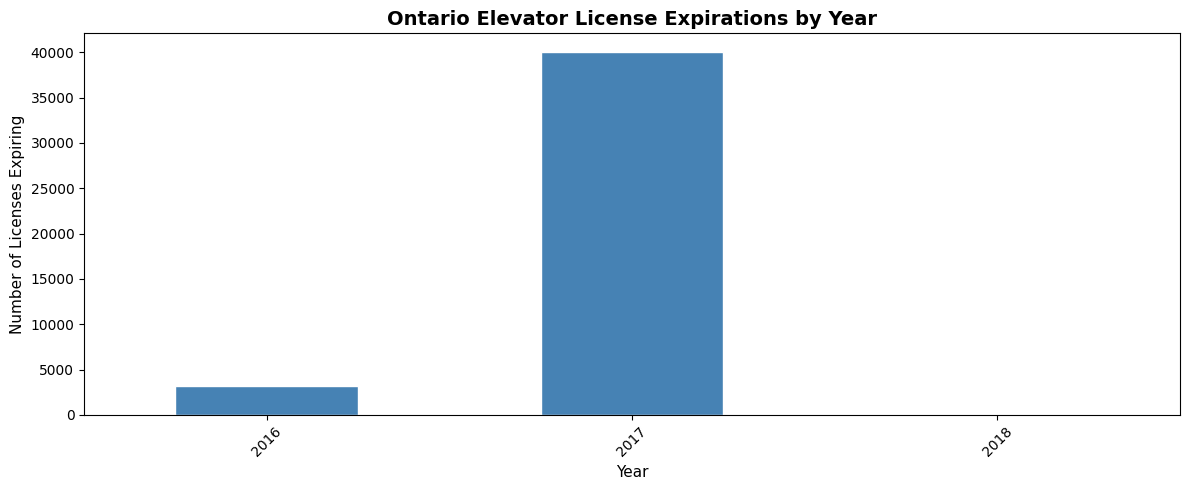

In [13]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12, 5))

yearly_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')

ax.set_title('Ontario Elevator License Expirations by Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=11)
ax.set_ylabel('Number of Licenses Expiring', fontsize=11)
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

**Justification:**

A bar chart was chosen because each bar maps directly to one year, making it easy for the operations manager to identify peak renewal years at a glance. A line chart would emphasize trends between years but can imply continuity between discrete yearly counts — a bar chart is more honest for this type of grouped data.

The time axis is derived entirely from the data using `dt.year` on the parsed `LICENSEEXPIRYDATE` column. No years were hard-coded — the x-axis reflects whatever years actually appear in the dataset.

The chart reveals when the bulk of the fleet's licenses are due for renewal, allowing the operations manager to anticipate workload spikes and plan renewal outreach accordingly. Years with high bars represent periods requiring the most administrative attention.

---
## Extra-Mile 2 — Two-Column Visualization

Group the filtered dataset by **License Status** and **Province** to reveal how each status is distributed across provinces.

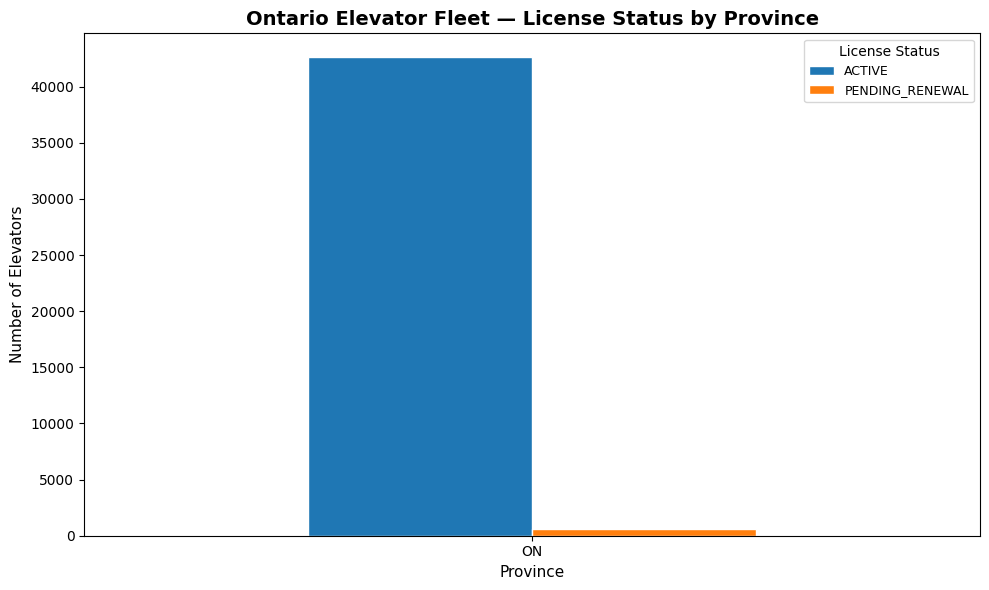

In [14]:
import matplotlib.pyplot as plt

# Group by Province and License Status, then unstack to get status as columns
grouped = df.groupby(['Province', 'LICENSESTATUS']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 6))

grouped.plot(kind='bar', ax=ax, edgecolor='white')

ax.set_title('Ontario Elevator Fleet — License Status by Province', fontsize=14, fontweight='bold')
ax.set_xlabel('Province', fontsize=11)
ax.set_ylabel('Number of Elevators', fontsize=11)
ax.legend(title='License Status', fontsize=9)
ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

**Analysis:**

This two-column chart reveals something the single-column charts from Task 6 could not: the relationship between where an elevator is located and what license status it holds. Ontario (ON) accounts for virtually the entire fleet, confirming that this is a provincial dataset. Within Ontario, ACTIVE licenses dominate overwhelmingly while PENDING_RENEWAL records represent only a small fraction — a ratio that would be invisible in a chart showing either column alone. The side-by-side bars make it immediately clear that PENDING_RENEWAL elevators are distributed across the same provinces as ACTIVE ones, suggesting renewals are a fleet-wide administrative pattern rather than a geographic anomaly concentrated in one region.